<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/hilbert_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy
!pip install pandas
!apt-get -qq install -y libfluidsynth1
!pip install seaborn
!pip install matplotlib-venn

E: Package 'libfluidsynth1' has no installation candidate


In [4]:
pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.

/tmp/ipython-input-152/2856110422.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


DEBUG (analyze_turning_points): prices shape: (252,), time_points shape: (252,)


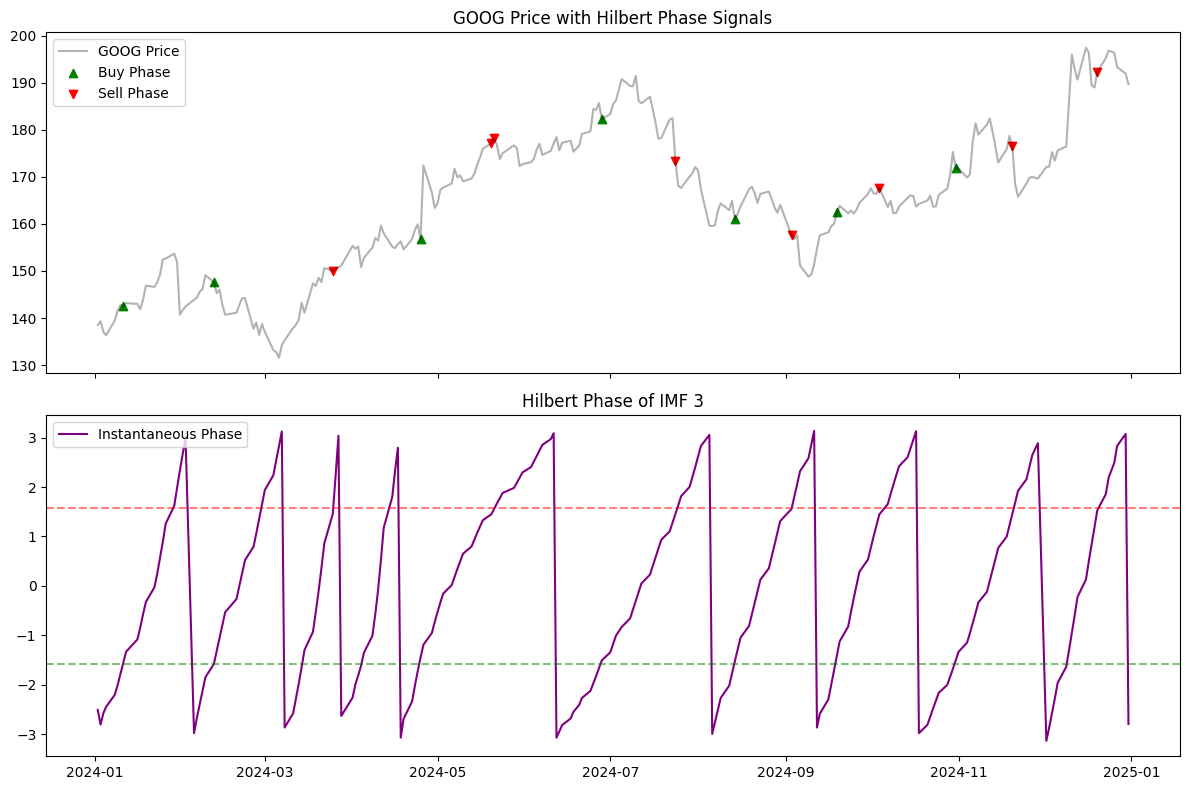

In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
from PyEMD import EMD
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def analyze_turning_points(ticker):
    # 1. เตรียมข้อมูล
    data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
    prices = data.values.ravel() # Ensure prices is a 1D array
    time_points = np.arange(len(prices)) # Define time points for EMD

    print(f"DEBUG (analyze_turning_points): prices shape: {prices.shape}, time_points shape: {time_points.shape}") # Debug print

    # 2. แยก IMF ด้วย EMD
    emd = EMD()
    imfs = emd(prices, time_points) # Pass time_points to EMD

    # เลือก IMF ลำดับที่ 3 (Cycle ระยะกลางที่มักมีนัยสำคัญต่อการเทรด)
    target_imf = imfs[2]

    # 3. ใช้ Hilbert Transform บน IMF ที่เลือก
    analytic_signal = hilbert(target_imf)
    phase = np.angle(analytic_signal) # ค่า Phase ระหว่าง -pi ถึง pi

    # 4. หาจุดกลับตัว (Local Max/Min ของ Phase)
    # จุดที่ Phase เข้าใกล้ pi/2 คือจุด Peak ของรอบ
    buy_signals = (phase < -1.4) & (phase > -1.6) # ใกล้ -pi/2
    sell_signals = (phase > 1.4) & (phase < 1.6)  # ใกล้ pi/2

    # 5. Visualizing
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # กราฟราคาและจุดสัญญาณ
    ax1.plot(data.index, prices, label=f'{ticker} Price', color='black', alpha=0.3)
    ax1.scatter(data.index[buy_signals], prices[buy_signals], color='green', marker='^', label='Buy Phase')
    ax1.scatter(data.index[sell_signals], prices[sell_signals], color='red', marker='v', label='Sell Phase')
    ax1.set_title(f'{ticker} Price with Hilbert Phase Signals')
    ax1.legend()

    # กราฟ Phase
    ax2.plot(data.index, phase, color='purple', label='Instantaneous Phase')
    ax2.axhline(y=np.pi/2, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=-np.pi/2, color='g', linestyle='--', alpha=0.5)
    ax2.set_title('Hilbert Phase of IMF 3')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Example usage:
analyze_turning_points('GOOG') # Add a ticker argument here

/tmp/ipython-input-152/994963653.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


DEBUG (analyze_with_amplitude_filter): prices shape: (252,), time_points shape: (252,)


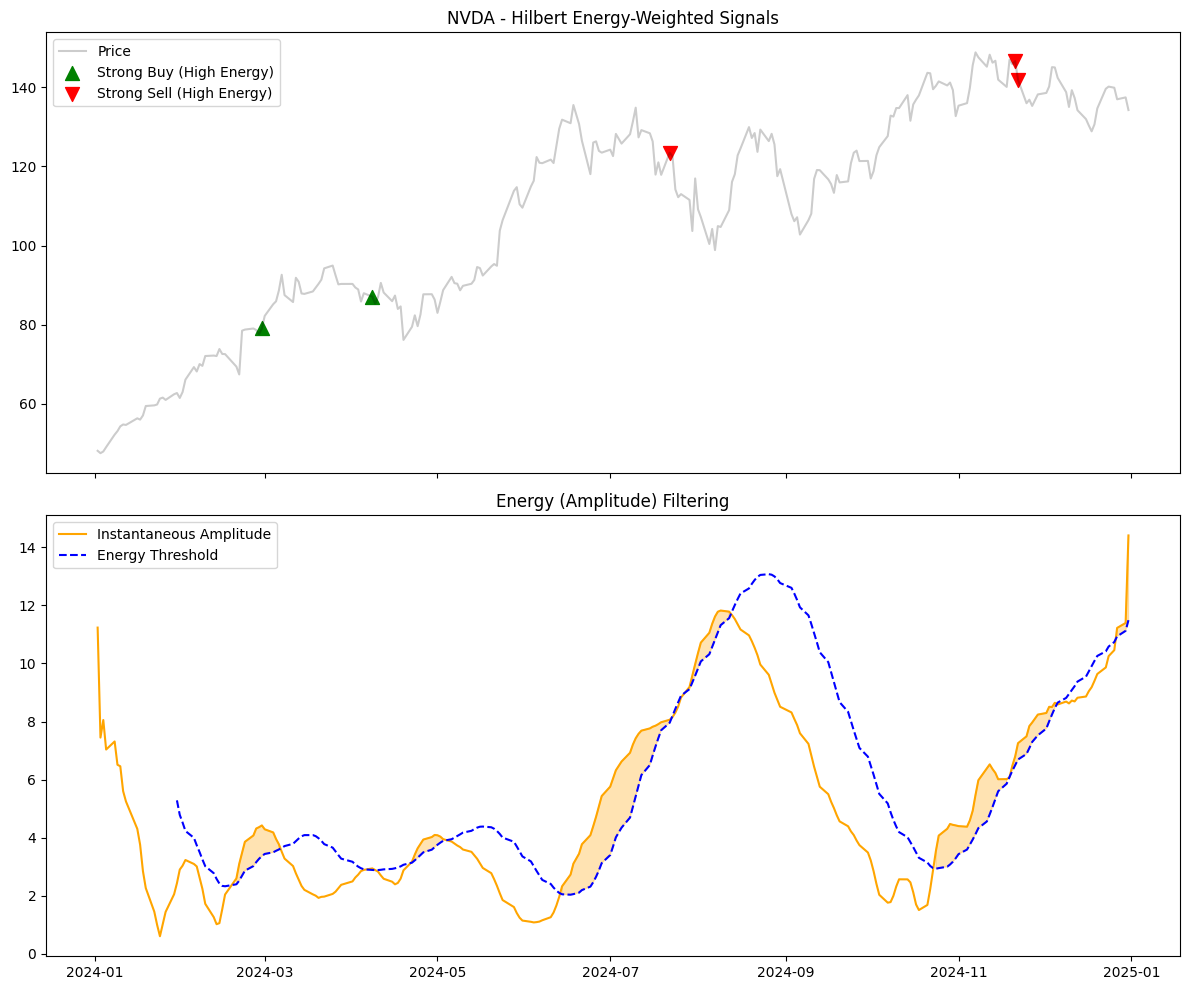

/tmp/ipython-input-152/994963653.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


DEBUG (analyze_with_amplitude_filter): prices shape: (252,), time_points shape: (252,)


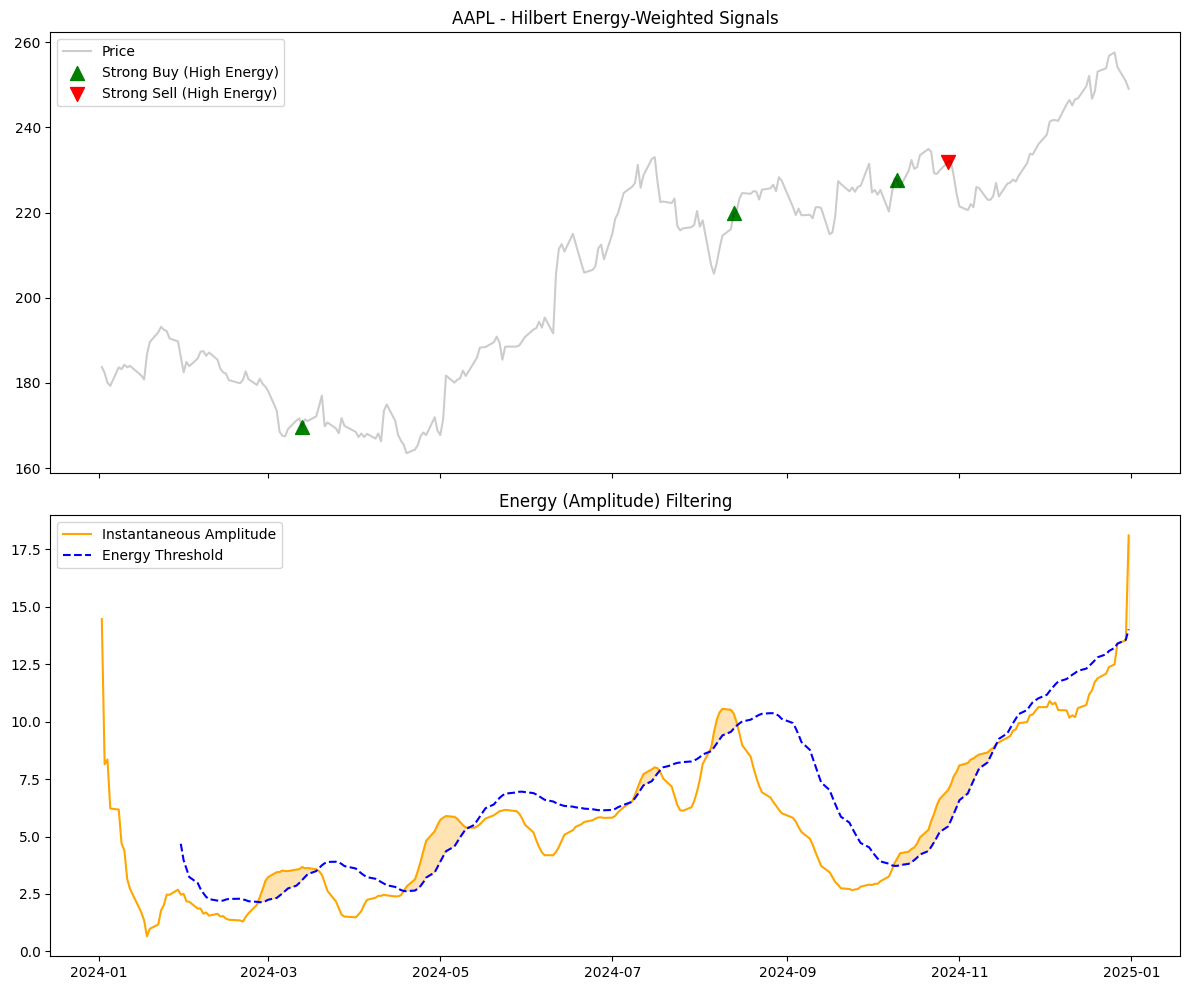

In [19]:
def analyze_with_amplitude_filter(ticker):
    # 1. ดึงข้อมูล
    data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
    prices = data.values.ravel() # Ensure prices is a 1D array
    time_points = np.arange(len(prices)) # Define time points for EMD

    print(f"DEBUG (analyze_with_amplitude_filter): prices shape: {prices.shape}, time_points shape: {time_points.shape}") # Debug print

    # 2. EMD Decomposition (เลือก IMF ที่ 3 เหมือนเดิม)
    emd = EMD()
    imfs = emd(prices, time_points) # Pass time_points to EMD
    target_imf = imfs[2]

    # 3. Hilbert Transform
    analytic_signal = hilbert(target_imf)
    amplitude = np.abs(analytic_signal)  # ความแรงของคลื่น
    phase = np.angle(analytic_signal)    # ตำแหน่งของคลื่น

    # 4. สร้างตัวกรอง Amplitude (ต้องสูงกว่าค่าเฉลี่ย 20 วัน)
    # Ensure amplitude Series has the same index as original data for correct rolling mean
    amp_series = pd.Series(amplitude, index=data.index)
    # Calculate threshold, converting to numpy array for comparison later
    amp_threshold_values = amp_series.rolling(window=20).mean() * 1.2

    # 5. สร้างสัญญาณ Buy/Sell
    # Buy: Phase ใกล้ -pi/2 และ Amplitude ต้องสูง
    buy_signals = (phase < -1.4) & (phase > -1.6) & (amplitude > amp_threshold_values.values)
    # Sell: Phase ใกล้ pi/2 และ Amplitude ต้องสูง
    sell_signals = (phase > 1.4) & (phase < 1.6) & (amplitude > amp_threshold_values.values)

    # 6. แสดงผล
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # กราฟราคาและจุดสัญญาณที่กรองแล้ว
    ax1.plot(data.index, prices, color='black', alpha=0.2, label='Price')
    ax1.scatter(data.index[buy_signals], prices[buy_signals], color='green', marker='^', s=100, label='Strong Buy (High Energy)')
    ax1.scatter(data.index[sell_signals], prices[sell_signals], color='red', marker='v', s=100, label='Strong Sell (High Energy)')
    ax1.set_title(f'{ticker} - Hilbert Energy-Weighted Signals')
    ax1.legend()

    # กราฟ Amplitude เปรียบเทียบกับ Threshold
    ax2.plot(data.index, amplitude, color='orange', label='Instantaneous Amplitude')
    ax2.plot(data.index, amp_threshold_values, color='blue', linestyle='--', label='Energy Threshold')
    ax2.fill_between(data.index, amplitude, amp_threshold_values.values, where=(amplitude > amp_threshold_values.values), color='orange', alpha=0.3)
    ax2.set_title('Energy (Amplitude) Filtering')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# วิเคราะห์ NVDA และ AAPL
analyze_with_amplitude_filter('NVDA')
analyze_with_amplitude_filter('AAPL')

/tmp/ipython-input-152/3880178270.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


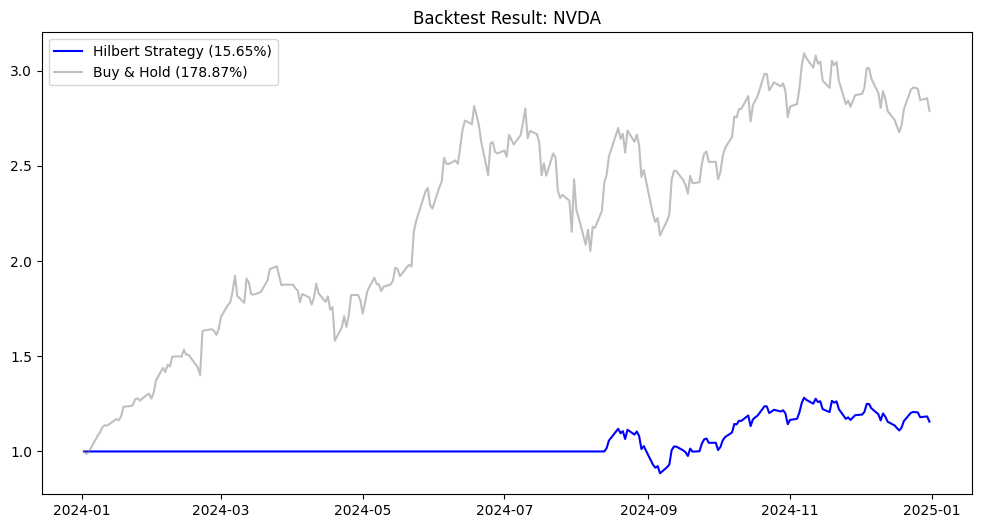

/tmp/ipython-input-152/3880178270.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed

--- NVDA Results ---
Strategy Return: 15.65%
Buy & Hold Return: 178.87%
Max Drawdown: -20.90%


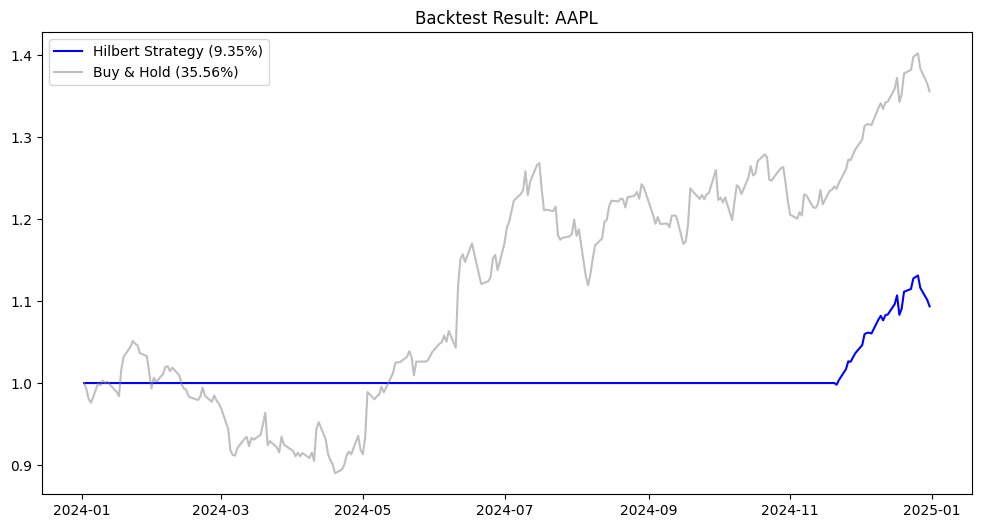

--- AAPL Results ---
Strategy Return: 9.35%
Buy & Hold Return: 35.56%
Max Drawdown: -3.32%


In [23]:
def backtest_hilbert_strategy(ticker):
    # 1. ดึงข้อมูล
    data = yf.download(ticker, start="2024-01-01", end="2025-01-01")['Close']
    prices = data.values.ravel() # Ensure prices is a 1D array
    time_points = np.arange(len(prices)) # Define time points for EMD

    # 2. EMD & Hilbert Analysis
    emd = EMD()
    imfs = emd(prices, time_points) # Pass time_points to EMD
    target_imf = imfs[min(len(imfs)-1, 3)] # เลือก IMF ที่สะท้อนรอบหลัก

    analytic_signal = hilbert(target_imf)
    amplitude = np.abs(analytic_signal)
    phase = np.angle(analytic_signal)

    # 3. สร้าง Signals
    # Ensure amp_threshold is aligned with data.index and comparison uses .values
    amp_series = pd.Series(amplitude, index=data.index)
    amp_threshold = amp_series.rolling(window=20).mean() * 1.1
    buy_signals = (phase < -1.4) & (phase > -1.6) & (amplitude > amp_threshold.values)
    sell_signals = (phase > 1.4) & (phase < 1.6) & (amplitude > amp_threshold.values)

    # 4. จำลองการเทรด
    position = 0 # 0: Cash, 1: Stock
    balance = 100000 # เงินต้น 100,000 บาท
    shares = 0
    history = []

    for i in range(len(prices)):
        # Ensure signals are converted to boolean arrays for indexing
        if buy_signals[i] and position == 0:
            shares = balance / prices[i]
            balance = 0
            position = 1
        elif sell_signals[i] and position == 1:
            balance = shares * prices[i]
            shares = 0
            position = 0

        # คำนวณมูลค่าพอร์ตปัจจุบัน
        current_val = balance + (shares * prices[i])
        history.append(current_val)

    # 5. คำนวณ Metrics
    history = pd.Series(history, index=data.index)
    bh_return = (prices[-1] / prices[0]) - 1 # prices is numpy, direct indexing is fine
    strategy_return = (history.iloc[-1] / history.iloc[0]) - 1 # Use iloc for positional access on Series

    # Drawdown
    dd = (history - history.cummax()) / history.cummax()
    max_dd = dd.min()

    # 6. แสดงผลเปรียบเทียบ
    plt.figure(figsize=(12, 6))
    plt.plot(history / history.iloc[0], label=f'Hilbert Strategy ({strategy_return:.2%})', color='blue') # Use iloc
    plt.plot(data / data.iloc[0], label=f'Buy & Hold ({bh_return:.2%})', color='gray', alpha=0.5) # Use iloc
    plt.title(f'Backtest Result: {ticker}')
    plt.legend()
    plt.show()

    print(f"--- {ticker} Results ---")
    print(f"Strategy Return: {strategy_return:.2%}")
    print(f"Buy & Hold Return: {bh_return:.2%}")
    print(f"Max Drawdown: {max_dd:.2%}")

# รัน Backtest
backtest_hilbert_strategy('NVDA')
backtest_hilbert_strategy('AAPL')